# MODELO CHURN - CLIENTES - SOPORTE

## HIPÓTESIS 

H1: Los clientes con un mayor número de interacciones con soporte presentan una mayor probabilidad de churn.

H2: LEl churn presenta diferencias según el tipo de zona geográfica del cliente.

H3: Los clientes de zonas rurales presentan una mayor probabilidad de churn que los clientes de zonas urbanas.

H4: Los clientes con planes de prepago presentan una mayor probabilidad de churn que los clientes con planes premium.

H5: Los clientes que contactan con soporte por incidencias relacionadas con cobertura o calidad de señal presentan una mayor probabilidad de churn.

In [2]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

In [55]:
df_churn= pd.read_csv(r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\churn_target.csv")
df_churn

,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0
...,...,...,...
321982,C010000,2025-08-01,0
321983,C010000,2025-09-01,0
321984,C010000,2025-10-01,0
321985,C010000,2025-11-01,0


In [4]:
df_clientes= pd.read_csv(r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\clientes.csv")
df_clientes.head()

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
1,C000002,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1
2,C000003,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0
3,C000004,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0
4,C000005,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0


In [5]:
df_soporte= pd.read_csv(r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\interacciones_soporte.csv")
df_soporte.head()

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.50,0,4.00,0.41,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.90,1,4.00,0.43,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.80,1,5.00,0.43,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.40,1,3.00,0.45,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.50,1,4.00,0.39,0,0,0


In [6]:
df_churn.isnull().sum()

cliente_id    0
fecha         0
churn         0
dtype: int64

In [61]:
df_churn['churn'].value_counts()

churn
0    319987
1      2000
Name: count, dtype: int64

In [7]:
df_churn.duplicated().sum()

np.int64(0)

### ELIMINACIÓN DUPLICADOS CLIENTES

In [8]:
df_clientes.duplicated().sum()

np.int64(150)

In [9]:
df_clientes['cliente_id'].duplicated().sum()

np.int64(150)

In [10]:
df_clientes[
    df_clientes['cliente_id'].duplicated(keep=False)
].sort_values('cliente_id')

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
5,C000006,Z30,Centro,suburbana,33966,37.00,M,Casado/a,3,Prepago,Gama media,"2,411.00",86.00,0
10033,C000006,Z30,Centro,suburbana,33966,37.00,M,Casado/a,3,Prepago,Gama media,"2,411.00",86.00,0
87,C000088,Z16,Este,urbana_premium,72683,18.00,M,Soltero/a,3,Contrato,Gama media,"2,492.00",25.00,0
10130,C000088,Z16,Este,urbana_premium,72683,18.00,M,Soltero/a,3,Contrato,Gama media,"2,492.00",25.00,0
100,C000101,Z28,Sur,urbana_premium,64486,22.00,M,Soltero/a,2,Premium,Gama alta,"4,181.00",NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9856,C009857,Z21,Centro,rural,19103,52.00,F,Casado/a,2,Prepago,Gama baja,"2,553.00",41.00,0
10032,C009898,Z26,Oeste,urbana_premium,107159,26.00,?,Soltero/a,3,Premium,Gama media,"4,275.00",7.00,1
9897,C009898,Z26,Oeste,urbana_premium,107159,26.00,?,Soltero/a,3,Premium,Gama media,"4,275.00",7.00,1
10062,C009950,Z17,Sur,suburbana,56619,37.00,X,Soltero/a,1,Premium,Gama media,"3,569.00",65.00,1


In [11]:
df_clientes = df_clientes.drop_duplicates()

In [12]:
df_clientes.isnull().sum()

cliente_id            0
zona_id               0
region                0
tipo_zona             0
poblacion_zona        0
edad                300
sexo                 45
estado_civil         77
num_lineas            0
tipo_plan             0
tipo_dispositivo      0
ingreso_estimado    300
antiguedad_meses    300
descuento_activo      0
dtype: int64

### ELIMINACIÓN NULOS CSV CLIENTES

In [13]:
df_clientes.describe()

,poblacion_zona,edad,num_lineas,ingreso_estimado,antiguedad_meses,descuento_activo
count,"10,000.00","9,700.00","10,000.00","9,700.00","9,700.00","10,000.00"
mean,"60,004.60",39.34,2.31,"3,476.79",32.55,0.26
std,"28,724.37",11.97,1.02,"1,411.89",22.53,0.44
min,"11,707.00",18.00,1.00,900.00,-110.00,0.00
25%,"41,163.00",31.00,2.00,"2,466.00",18.00,0.00
50%,"56,342.00",39.00,2.00,"3,219.00",29.00,0.00
75%,"72,683.00",47.00,3.00,"4,194.25",44.00,1.00
max,"107,159.00",80.00,5.00,"12,000.00",120.00,1.00


In [14]:
df_clientes['edad'] = df_clientes['edad'].fillna(
    df_clientes['edad'].median()
)

In [15]:
df_clientes['ingreso_estimado'] = df_clientes['ingreso_estimado'].fillna(
    df_clientes['ingreso_estimado'].median()
)

In [16]:
df_clientes['antiguedad_meses'] = df_clientes['antiguedad_meses'].fillna(
    df_clientes['antiguedad_meses'].median()
)

In [17]:
df_clientes['sexo'] = df_clientes['sexo'].fillna('Desconocido')

In [18]:
df_clientes['estado_civil'] = df_clientes['estado_civil'].fillna('Desconocido')

In [19]:
df_clientes.isnull().sum()

cliente_id          0
zona_id             0
region              0
tipo_zona           0
poblacion_zona      0
edad                0
sexo                0
estado_civil        0
num_lineas          0
tipo_plan           0
tipo_dispositivo    0
ingreso_estimado    0
antiguedad_meses    0
descuento_activo    0
dtype: int64

In [20]:
df_soporte.duplicated().sum()

np.int64(4558)

In [21]:
duplicados = df_soporte[
    df_soporte['interaccion_id'].duplicated(
        keep=False
    )
]

duplicados.head(20)

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
212,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.00,0,2.00,0.39,0,0,0
248,I271008632610,C000008,2023-10-04,2023-10-01,telefono,Cambio de plan,4.10,1,5.00,0.41,0,0,0
255,I831660710653,C000008,2024-04-25,2024-04-01,app_chat,Calidad de señal,8.00,1,3.00,0.30,0,0,0
317,I666962040807,C000010,2025-08-20,2025-08-01,telefono,Consulta general,4.90,0,5.00,0.40,0,0,0
326,I721437122731,C000011,2023-04-14,2023-04-01,telefono,Baja / portabilidad,10.80,0,3.00,0.54,0,0,0
444,I747915945768,C000013,2025-06-15,2025-06-01,tienda,Calidad de señal,1.00,1,5.00,0.36,0,0,0
563,I705123563177,C000017,2024-08-25,2024-08-01,tienda,Facturación,2.60,0,3.00,0.48,0,1,41
572,I801443917956,C000018,2023-04-15,2023-04-01,app_chat,Calidad de señal,3.70,1,3.00,0.52,0,0,0
579,I748444381545,C000018,2023-09-16,2023-09-01,telefono,Cobertura / velocidad,1.20,0,2.00,0.54,0,0,0
725,I389032705098,C000023,2023-08-10,2023-08-01,app_chat,Impago / pago,7.30,1,4.00,0.39,0,1,28


In [22]:
df_soporte[
    df_soporte['interaccion_id'] == 'I716491295118'
]

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
212,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.00,0,2.00,0.39,0,0,0
303947,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.00,0,2.00,0.39,0,0,0


In [23]:
df_soporte = df_soporte.drop_duplicates()

In [24]:
df_soporte['interaccion_id'].duplicated().sum()

np.int64(0)

### ELIMINAR NULOS DEL CSV DE SOPORTE

In [25]:
df_soporte['interaccion_id'].duplicated().sum()

np.int64(0)

In [26]:
df_soporte.isnull().sum()

interaccion_id              0
cliente_id                  0
fecha_evento                0
mes                         0
canal                       0
motivo                   4558
duracion_min                0
resuelto                    0
satisfaccion_post        4558
stress_calidad_lag          0
incidencia_masiva_lag       0
impago_mes                  0
dias_retraso_mes            0
dtype: int64

### ELIMINACIÓN NULOS DEL CSV DE SOPORTE


In [27]:
df_soporte['motivo'] = df_soporte['motivo'].fillna('Desconocido')

In [28]:
df_soporte['sin_satisfaccion'] = (
    df_soporte['satisfaccion_post']
    .isnull()
    .astype(int)
)

In [29]:
df_soporte['satisfaccion_post'] = (
    df_soporte['satisfaccion_post']
    .fillna(-1)
)

La variable satisfaccion_post presentaba valores faltantes asociados probablemente a clientes que no respondieron la encuesta posterior a la interacción. En lugar de eliminar registros, se decidió conservar la información creando una categoría diferenciada para ausencia de respuesta, evitando así pérdida innecesaria de datos.

In [30]:
df_soporte.isnull().sum()

interaccion_id           0
cliente_id               0
fecha_evento             0
mes                      0
canal                    0
motivo                   0
duracion_min             0
resuelto                 0
satisfaccion_post        0
stress_calidad_lag       0
incidencia_masiva_lag    0
impago_mes               0
dias_retraso_mes         0
sin_satisfaccion         0
dtype: int64

## Granularidad -

 Que representa cada fila del dataset

*Churn*: Clientes/mes

*Cliente*: Cliente

*Soporte*: Cliente/ Interacción con soporte

In [31]:
# Vamos a convertir soporte a clientes-mes

soporte_agg = df_soporte.groupby(
    ['cliente_id', 'mes']
).agg({
    'interaccion_id':'count',
    'duracion_min':'mean',
    'resuelto':'mean',
    'satisfaccion_post':'mean'
}).reset_index()

In [32]:
soporte_agg.rename(columns={
    'interaccion_id':'num_interacciones',
    'duracion_min':'duracion_media',
    'resuelto':'pct_resuelto',
    'satisfaccion_post':'satisfaccion_media'
}, inplace=True)

In [33]:
df_churn.head()

,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


In [34]:
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 321987 entries, 0 to 321986
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   cliente_id  321987 non-null  str  
 1   fecha       321987 non-null  str  
 2   churn       321987 non-null  int64
dtypes: int64(1), str(2)
memory usage: 7.4 MB


In [41]:
#Renonmbramos la columna para que tenga el mismo nombre y se pueda hacer el merge
df_churn = df_churn.rename(
    columns={'fecha':'mes'}
)

In [42]:
#Nos aseguramos de que ambas columnas estén en el formato correcto de tiempo
df_churn['mes'] = pd.to_datetime(
    df_churn['mes']
)

soporte_agg['mes'] = pd.to_datetime(
    soporte_agg['mes']
)

In [44]:
#Juntamos la tabla con la de soporte_agg
df_modelo = df_churn.merge(
    soporte_agg,
    on=['cliente_id', 'mes'],
    how='left'
)

In [45]:
#Añadimos la tabla de clientes
df_modelo = df_modelo.merge(
    df_clientes,
    on='cliente_id',
    how='left'
)

In [40]:
df_modelo

,cliente_id,mes,churn,num_interacciones,duracion_media,pct_resuelto,satisfaccion_media,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,2023-01-01,0,0.00,0.00,0.00,0.00,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
1,C000001,2023-02-01,0,1.00,9.50,0.00,4.00,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
2,C000001,2023-03-01,0,0.00,0.00,0.00,0.00,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
3,C000001,2023-04-01,0,2.00,3.35,1.00,4.50,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
4,C000001,2023-05-01,0,1.00,8.40,1.00,3.00,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321982,C010000,2025-08-01,0,0.00,0.00,0.00,0.00,Z16,Este,urbana_premium,72683,52.00,M,Casado/a,5,Premium,Gama media,"3,016.00",64.00,0
321983,C010000,2025-09-01,0,0.00,0.00,0.00,0.00,Z16,Este,urbana_premium,72683,52.00,M,Casado/a,5,Premium,Gama media,"3,016.00",64.00,0
321984,C010000,2025-10-01,0,1.00,1.00,1.00,4.00,Z16,Este,urbana_premium,72683,52.00,M,Casado/a,5,Premium,Gama media,"3,016.00",64.00,0
321985,C010000,2025-11-01,0,0.00,0.00,0.00,0.00,Z16,Este,urbana_premium,72683,52.00,M,Casado/a,5,Premium,Gama media,"3,016.00",64.00,0


In [47]:
df_modelo.duplicated().sum()

np.int64(0)

In [48]:
df_modelo.isnull().sum()

cliente_id                 0
mes                        0
churn                      0
num_interacciones     142879
duracion_media        142879
pct_resuelto          142879
satisfaccion_media    142879
zona_id                    0
region                     0
tipo_zona                  0
poblacion_zona             0
edad                       0
sexo                       0
estado_civil               0
num_lineas                 0
tipo_plan                  0
tipo_dispositivo           0
ingreso_estimado           0
antiguedad_meses           0
descuento_activo           0
dtype: int64

estos nulos son normales ya que son de clientes que no han realizado llamadas a soporte

In [49]:
cols_soporte = [
    'num_interacciones',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media'
]

df_modelo[cols_soporte] = (
    df_modelo[cols_soporte]
    .fillna(0)
)

In [50]:
df_modelo.isnull().sum()

cliente_id            0
mes                   0
churn                 0
num_interacciones     0
duracion_media        0
pct_resuelto          0
satisfaccion_media    0
zona_id               0
region                0
tipo_zona             0
poblacion_zona        0
edad                  0
sexo                  0
estado_civil          0
num_lineas            0
tipo_plan             0
tipo_dispositivo      0
ingreso_estimado      0
antiguedad_meses      0
descuento_activo      0
dtype: int64

In [69]:
# =========================
# 1. Crear target a nivel cliente
# =========================

churn_cliente = (
    df_churn.groupby('cliente_id')['churn']
    .max()
    .reset_index()
)

# =========================
# 2. Crear agregados de soporte a nivel cliente
# =========================

soporte_cliente = (
    df_soporte.groupby('cliente_id')
    .agg({
        'interaccion_id':'count',
        'duracion_min':'mean',
        'resuelto':'mean',
        'satisfaccion_post':'mean'
    })
    .reset_index()
)

# =========================
# 3. Renombrar columnas
# =========================

soporte_cliente.rename(columns={
    'interaccion_id':'num_interacciones',
    'duracion_min':'duracion_media',
    'resuelto':'pct_resuelto',
    'satisfaccion_post':'satisfaccion_media'
}, inplace=True)

# =========================
# 4. Unir churn + clientes
# =========================

df_modelo_final = churn_cliente.merge(
    df_clientes,
    on='cliente_id',
    how='left'
)

# =========================
# 5. Añadir soporte agregado
# =========================

df_modelo_final = df_modelo_final.merge(
    soporte_cliente,
    on='cliente_id',
    how='left'
)

# =========================
# 6. Rellenar NaN de soporte
# =========================

cols_soporte = [
    'num_interacciones',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media'
]

df_modelo_final[cols_soporte] = (
    df_modelo_final[cols_soporte]
    .fillna(0)
)

# =========================
# 7. Verificar resultado
# =========================

df_modelo_final.head()

df_modelo_final['churn'].value_counts()

df_modelo_final

,cliente_id,churn,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo,num_interacciones,duracion_media,pct_resuelto,satisfaccion_media
0,C000001,0,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0,23.00,6.10,0.52,3.30
1,C000002,0,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1,38.00,6.78,0.68,3.58
2,C000003,1,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0,43.00,5.13,0.72,3.60
3,C000004,0,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0,37.00,5.38,0.65,3.62
4,C000005,0,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0,34.00,5.63,0.65,3.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,C009996,0,Z15,Oeste,suburbana,62939,43.00,F,Soltero/a,2,Prepago,Gama baja,"2,097.00",28.00,0,30.00,5.49,0.50,3.07
9996,C009997,1,Z10,Este,suburbana,27514,49.00,M,Casado/a,2,Contrato,Gama media,"1,609.00",12.00,1,34.00,6.80,0.50,3.09
9997,C009998,0,Z05,Este,urbana_premium,94471,28.00,F,Casado/a,3,Prepago,Gama alta,"4,949.00",29.00,0,33.00,6.52,0.58,3.55
9998,C009999,0,Z13,Este,suburbana,37333,48.00,F,Casado/a,4,Premium,Gama alta,"4,406.00",47.00,1,28.00,4.55,0.39,3.11


# VISUALIZACIÓN VARIABLES

H1: Los clientes con un mayor número de interacciones con soporte presentan una mayor probabilidad de churn.

H2: LEl churn presenta diferencias según el tipo de zona geográfica del cliente.

H3: Los clientes de zonas rurales presentan una mayor probabilidad de churn que los clientes de zonas urbanas.

H4: Los clientes con planes de prepago presentan una mayor probabilidad de churn que los clientes con planes premium.

H5: Los clientes que contactan con soporte por incidencias relacionadas con cobertura o calidad de señal presentan una mayor probabilidad de churn.

In [70]:
df_modelo_final['num_interacciones'].describe()

count   10,000.00
mean        30.39
std         12.51
min          0.00
25%         22.00
50%         30.00
75%         38.00
max         82.00
Name: num_interacciones, dtype: float64

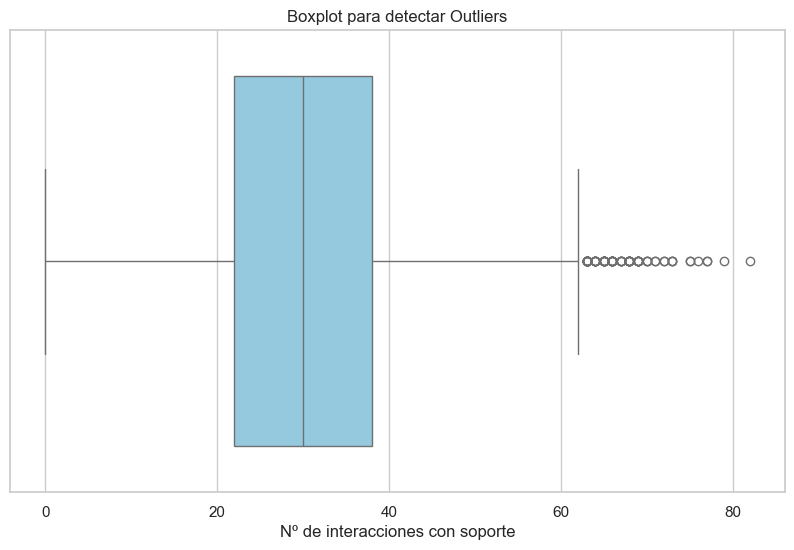

In [73]:

plt.figure(figsize=(10, 6)) # Ajusta el tamaño si lo necesitas
sns.boxplot(x=df_modelo_final['num_interacciones'], color='skyblue')

plt.title('Boxplot para detectar Outliers')
plt.xlabel('Nº de interacciones con soporte')
plt.show()


En este caso no eliminamos los outliers ya que pueden ser de clientes que lleven mucho tiempo llamando a servicio técnico o hayan tenido muchos problemas

### CONTRASTE HIPÓTESIS


In [64]:
df_modelo_final['churn'].value_counts()

churn
0    8000
1    2000
Name: count, dtype: int64

In [66]:
df_modelo_final['num_interacciones'].value_counts().sort_index()

num_interacciones
0.00     27
1.00     20
2.00     48
3.00     44
4.00     62
         ..
75.00     2
76.00     1
77.00     2
79.00     1
82.00     1
Name: count, Length: 79, dtype: int64

In [76]:
# Agrupamos las interacciones para ver patrones
df_modelo_final['grupo_interacciones'] = pd.cut(
    df_modelo_final['num_interacciones'],
    bins=[-1,0,5,15,30,100],
    labels=[
        '0',
        '1-5',
        '6-15',
        '16-30',
        '30+'
    ]
)

In [77]:
df_modelo_final.groupby(
    'grupo_interacciones'
)['churn'].mean()

grupo_interacciones
0       1.00
1-5     1.00
6-15    0.82
16-30   0.17
30+     0.08
Name: churn, dtype: float64

In [78]:
df_modelo_final['churn'].value_counts()

churn
0    8000
1    2000
Name: count, dtype: int64

In [79]:
df_churn.groupby(
    'cliente_id'
)['churn'].sum().describe()

count   10,000.00
mean         0.20
std          0.40
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          1.00
Name: churn, dtype: float64

In [80]:
df_modelo_final['grupo_interacciones'].value_counts()

grupo_interacciones
30+      4720
16-30    4239
6-15      791
1-5       223
0          27
Name: count, dtype: int64

In [81]:
pd.crosstab(
    df_modelo_final['grupo_interacciones'],
    df_modelo_final['churn'],
    normalize='index'
)

churn,0,1
grupo_interacciones,,
0,0.00,1.00
1-5,0.00,1.00
6-15,0.18,0.82
16-30,0.83,0.17
30+,0.92,0.08


    Con esto vemos lo que puede pasar si se cambia la granularidad de una base de datos, número de interacciones a pasado de reflejar la posible frustración del cliente a la cantidad total acumulada durante la vida del cliente